# Fáza 3 - Strojové učenie

Kosharova, Oliinyk

## Import knižníc

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn imports
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

## Načítanie dát z fázy 2

In [2]:
# Načítanie metadát z fázy 2
metadata = joblib.load('phase2_metadata.pkl')

print("Načítané metadáta:")
print(f"- Počet vybraných príznakov: {len(metadata['selected_features'])}")
print(f"- Pipeline: {metadata['pipeline']}")
print(f"\nVybrané príznaky: {metadata['selected_features'][:10]}...")  # Prvých 10

Načítané metadáta:
- Počet vybraných príznakov: 27
- Pipeline: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('normal', StandardScaler(),
                                                  ['HR', 'RR', 'Hb level',
                                                   'latitude', 'longitude']),
                                                 ('skewed', PowerTransformer(),
                                                  ['PRV', 'PVI', 'EtCO₂',
                                                   'Skin Temperature',
                                                   'Motion/Activity index']),
                                                 ('outliers', RobustScaler(),
                                                  ['BP', 'PI', 'SV', 'CO',
                                                   'Blood Flow Index', 'SNR',
                                                   'Signal Quality Index',
                                                   'PPG waveform

In [3]:
y_train = pd.read_csv("splits/y_train.csv").squeeze()
y_test = pd.read_csv("splits/y_test.csv").squeeze()

In [4]:
# Načítanie originálnych dát (upravte cestu podľa vašich dát)
# Predpokladáme, že máte trénovacie a testovacie dáta z fázy 2
X_train = pd.read_csv("splits/X_train.csv")# Upravte podľa potreby
X_test = X_test = pd.read_csv("splits/X_test.csv")    # Upravte podľa potreby

# Pre účely klasifikácie potrebujeme diskretizovať cieľovú premennú
# Príklad: konverzia regresného problému na klasifikačný
y_train_class = pd.cut(y_train, bins=3, labels=['Low', 'Medium', 'High'])
y_test_class = pd.cut(y_test, bins=3, labels=['Low', 'Medium', 'High'])

# POZNÁMKA: Nahraďte tento kód načítaním vašich skutočných dát
# print("⚠️ Upravte túto bunku pre načítanie vašich trénovacích a testovacích dát")
# print("⚠️ Ak je váš problém regresný, diskretizujte cieľovú premennú pomocou pd.cut()")

## Príprava dát

Transformujeme dáta pomocou pipeline z fázy 2 a pripravíme ich pre klasifikáciu.

In [5]:
# Transformácia dát pomocou pipeline
pipeline = metadata['pipeline']

X_train_transformed = pipeline.transform(X_train)
X_test_transformed = pipeline.transform(X_test)

# # Vytvorenie DataFrame s transformovanými dátami
X_train_df = pd.DataFrame(
    X_train_transformed,
    columns=metadata['selected_features'],
    index=X_train.index
)

X_test_df = pd.DataFrame(
    X_test_transformed,
    columns=metadata['selected_features'],
    index=X_test.index
)

print(f"Trénovacie dáta: {X_train_df.shape}")
print(f"Testovacie dáta: {X_test_df.shape}")
print(f"\nDistribúcia tried v trénovacích dátach:")
print(y_train_class.value_counts())

Trénovacie dáta: (17260, 27)
Testovacie dáta: (4315, 27)

Distribúcia tried v trénovacích dátach:
oximetry
High      10308
Low        6952
Medium        0
Name: count, dtype: int64


## 3.1 Jednoduchý ID3 klasifikátor


### 3.1.A - Implementácia ID3 klasifikátora (2b)

In [6]:
class ID3Node:
    """Uzol v ID3 rozhodovcom strome."""
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature      # Index príznaku pre delenie
        self.threshold = threshold  # Prahová hodnota pre delenie
        self.left = left           # Ľavý podstrom (hodnoty <= threshold)
        self.right = right         # Pravý podstrom (hodnoty > threshold)
        self.value = value         # Predikovaná trieda (len pre listy)


class ID3Classifier:
    """Vlastná implementácia ID3 algoritmu pre klasifikáciu."""
    
    def __init__(self, max_depth=2, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None
        self.feature_names = None
        
    def _entropy(self, y):
        """Vypočíta entropiu."""
        hist = np.bincount(y)
        ps = hist / len(y)
        return -np.sum([p * np.log2(p) for p in ps if p > 0])
    
    def _information_gain(self, X_column, y, threshold):
        """Vypočíta information gain pre dané delenie."""
        parent_entropy = self._entropy(y)
        
        # Vytvorenie masiek pre delenie
        left_mask = X_column <= threshold
        right_mask = X_column > threshold
        
        if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
            return 0
        
        # Výpočet váženej entropie potomkov
        n = len(y)
        n_left, n_right = np.sum(left_mask), np.sum(right_mask)
        e_left, e_right = self._entropy(y[left_mask]), self._entropy(y[right_mask])
        child_entropy = (n_left / n) * e_left + (n_right / n) * e_right
        
        return parent_entropy - child_entropy
    
    def _best_split(self, X, y):
        """Nájde najlepšie delenie."""
        best_gain = -1
        best_feature = None
        best_threshold = None
        
        n_features = X.shape[1]
        
        for feature_idx in range(n_features):
            X_column = X[:, feature_idx]
            thresholds = np.unique(X_column)
            
            for threshold in thresholds:
                gain = self._information_gain(X_column, y, threshold)
                
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature_idx
                    best_threshold = threshold
        
        return best_feature, best_threshold, best_gain
    
    def _build_tree(self, X, y, depth=0):
        """Rekurzívne buduje strom."""
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))
        
        # Podmienky zastavenia
        if (depth >= self.max_depth or 
            n_labels == 1 or 
            n_samples < self.min_samples_split):
            leaf_value = self._most_common_label(y)
            return ID3Node(value=leaf_value)
        
        # Nájdenie najlepšieho delenia
        best_feature, best_threshold, best_gain = self._best_split(X, y)
        
        if best_gain == 0:
            leaf_value = self._most_common_label(y)
            return ID3Node(value=leaf_value)
        
        # Vytvorenie potomkov
        left_idxs = X[:, best_feature] <= best_threshold
        right_idxs = X[:, best_feature] > best_threshold
        
        left = self._build_tree(X[left_idxs], y[left_idxs], depth + 1)
        right = self._build_tree(X[right_idxs], y[right_idxs], depth + 1)
        
        return ID3Node(best_feature, best_threshold, left, right)
    
    def _most_common_label(self, y):
        """Vráti najčastejšiu triedu."""
        counter = Counter(y)
        return counter.most_common(1)[0][0]
    
    def fit(self, X, y, feature_names=None):
        """Natrénuje ID3 klasifikátor."""
        if isinstance(X, pd.DataFrame):
            self.feature_names = X.columns.tolist()
            X = X.values
        else:
            self.feature_names = feature_names
        
        if isinstance(y, pd.Series):
            y = y.values
        
        # Konverzia tried na číselné hodnoty
        self.classes_ = np.unique(y)
        self.class_to_idx = {c: i for i, c in enumerate(self.classes_)}
        y_encoded = np.array([self.class_to_idx[c] for c in y])
        
        self.root = self._build_tree(X, y_encoded)
        return self
    
    def _traverse_tree(self, x, node):
        """Prechádza stromom pre jeden vstup."""
        if node.value is not None:
            return node.value
        
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)
    
    def predict(self, X):
        """Predikuje triedy pre vstupné dáta."""
        if isinstance(X, pd.DataFrame):
            X = X.values
        
        predictions = [self._traverse_tree(x, self.root) for x in X]
        # Konverzia späť na originálne triedy
        idx_to_class = {i: c for c, i in self.class_to_idx.items()}
        return np.array([idx_to_class[p] for p in predictions])
    
    def print_tree(self, node=None, depth=0):
        """Vypíše štruktúru stromu."""
        if node is None:
            node = self.root
        
        if node.value is not None:
            print(f"{'  ' * depth}Predikcia: {self.classes_[node.value]}")
        else:
            feature_name = (self.feature_names[node.feature] 
                          if self.feature_names else f"Feature {node.feature}")
            print(f"{'  ' * depth}{feature_name} <= {node.threshold:.3f}")
            print(f"{'  ' * depth}├── Left:")
            self.print_tree(node.left, depth + 1)
            print(f"{'  ' * depth}└── Right:")
            self.print_tree(node.right, depth + 1)


print("✓ ID3 klasifikátor implementovaný")

✓ ID3 klasifikátor implementovaný


In [7]:
# Trénovanie ID3 klasifikátora
id3_clf = ID3Classifier(max_depth=2, min_samples_split=10)
id3_clf.fit(X_train_df, y_train_class)

print("Štruktúra ID3 stromu:")
print("=" * 50)
id3_clf.print_tree()

Štruktúra ID3 stromu:
skewed__PVI <= 0.035
├── Left:
  skewed__PRV <= -0.686
  ├── Left:
    Predikcia: Low
  └── Right:
    Predikcia: Low
└── Right:
  skewed__PVI <= 0.468
  ├── Left:
    Predikcia: High
  └── Right:
    Predikcia: High


### 3.1.B - Vyhodnotenie ID3 klasifikátora (1b)

In [8]:
def evaluate_classifier(y_true, y_pred, model_name="Model"):
    """Vyhodnotí klasifikátor pomocou štandardných metrík."""
    accuracy = accuracy_score(y_true, y_pred)
    
    # Pre multi-class klasifikáciu použijeme 'weighted' average
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    print(f"\n{'='*60}")
    print(f"{model_name} - Metriky výkonnosti")
    print(f"{'='*60}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"{'='*60}\n")
    
    # Detailný report
    print("Detailný classification report:")
    print(classification_report(y_true, y_pred, zero_division=0))
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_true))
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.tight_layout()
    plt.show()
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }


ID3 (Train) - Metriky výkonnosti
Accuracy:  0.8048
Precision: 0.8264
Recall:    0.8048
F1-Score:  0.8066

Detailný classification report:
              precision    recall  f1-score   support

        High       0.91      0.75      0.82     10308
         Low       0.70      0.89      0.79      6952

    accuracy                           0.80     17260
   macro avg       0.81      0.82      0.80     17260
weighted avg       0.83      0.80      0.81     17260



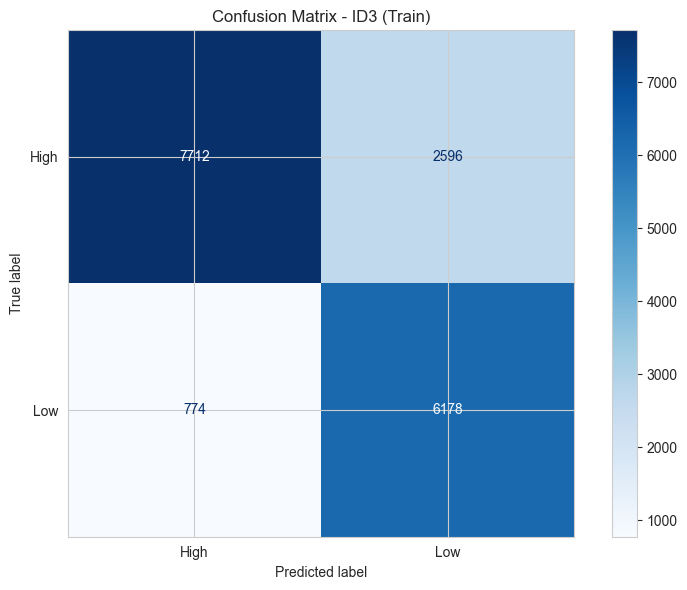


ID3 (Test) - Metriky výkonnosti
Accuracy:  0.7975
Precision: 0.8205
Recall:    0.7975
F1-Score:  0.7996

Detailný classification report:
              precision    recall  f1-score   support

        High       0.90      0.74      0.82      2600
         Low       0.69      0.88      0.78      1715

    accuracy                           0.80      4315
   macro avg       0.80      0.81      0.80      4315
weighted avg       0.82      0.80      0.80      4315



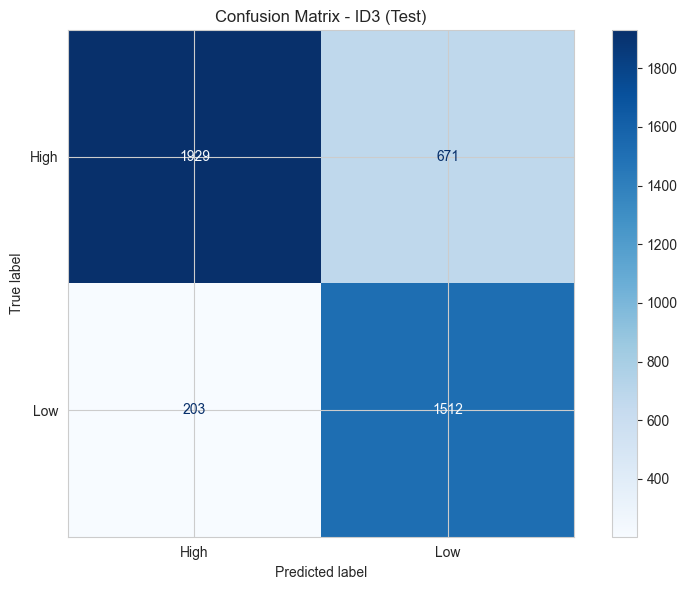

In [9]:
# Predikcia a vyhodnotenie ID3
y_pred_id3_train = id3_clf.predict(X_train_df)
y_pred_id3_test = id3_clf.predict(X_test_df)

# print("\n📊 Výsledky na TRÉNOVACÍCH dátach:")
id3_train_metrics = evaluate_classifier(y_train_class, y_pred_id3_train, "ID3 (Train)")

# print("\n📊 Výsledky na TESTOVACÍCH dátach:")
id3_test_metrics = evaluate_classifier(y_test_class, y_pred_id3_test, "ID3 (Test)")

### 3.1.C - Analýza overfittingu (2b)

In [10]:
def check_overfitting(train_metrics, test_metrics, threshold=0.1):
    """Kontroluje prítomnosť overfittingu."""
    print("\n🔍 Analýza overfittingu:")
    print("="*60)
    
    acc_diff = train_metrics['accuracy'] - test_metrics['accuracy']
    prec_diff = train_metrics['precision'] - test_metrics['precision']
    rec_diff = train_metrics['recall'] - test_metrics['recall']
    
    print(f"Rozdiel v accuracy:  {acc_diff:.4f}")
    print(f"Rozdiel v precision: {prec_diff:.4f}")
    print(f"Rozdiel v recall:    {rec_diff:.4f}")
    
    has_overfit = any([abs(d) > threshold for d in [acc_diff, prec_diff, rec_diff]])
    
    if has_overfit:
        print(f"\n⚠️ OVERFIT DETEKOVANÝ! (prah: {threshold})")
        print("   Model dosahuje výrazne lepšie výsledky na trénovacích dátach.")
        return True
    else:
        print(f"\n✓ Overfit nie je detekovaný (prah: {threshold})")
        return False

In [11]:
has_overfit = check_overfitting(id3_train_metrics, id3_test_metrics)


🔍 Analýza overfittingu:
Rozdiel v accuracy:  0.0073
Rozdiel v precision: 0.0059
Rozdiel v recall:    0.0073

✓ Overfit nie je detekovaný (prah: 0.1)


In [12]:
# Riešenie overfittingu - experimenty s hyperparametrami
if has_overfit:
    print("\n🔧 Riešenie overfittingu pomocou úpravy hyperparametrov...\n")
    
    # Testovanie rôznych nastavení
    configs = [
        {'max_depth': 2, 'min_samples_split': 20},
        {'max_depth': 2, 'min_samples_split': 50},
        {'max_depth': 3, 'min_samples_split': 30},
    ]
    
    best_diff = float('inf')
    best_config = None
    best_model = None
    
    for config in configs:
        clf = ID3Classifier(**config)
        clf.fit(X_train_df, y_train_class)
        
        y_pred_train = clf.predict(X_train_df)
        y_pred_test = clf.predict(X_test_df)
        
        train_acc = accuracy_score(y_train_class, y_pred_train)
        test_acc = accuracy_score(y_test_class, y_pred_test)
        diff = abs(train_acc - test_acc)
        
        print(f"Config {config}: Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f}, Diff={diff:.4f}")
        
        if diff < best_diff:
            best_diff = diff
            best_config = config
            best_model = clf
    
    print(f"\n✓ Najlepšia konfigurácia: {best_config}")
    print(f"  Rozdiel v accuracy: {best_diff:.4f}")
    
    # Aktualizácia modelu
    id3_clf = best_model
    y_pred_id3_test = id3_clf.predict(X_test_df)
    id3_test_metrics = evaluate_classifier(y_test_class, y_pred_id3_test, "ID3 (Optimalizovaný)")

## 3.2 Porovnanie s inými algoritmami

Porovnanie ID3 s ostatnými klasifikačnými algoritmami zo scikit-learn.

### 3.2.A - Stromový algoritmus (1b)


📊 Výsledky Decision Tree na TESTOVACÍCH dátach:

Decision Tree (sklearn) - Metriky výkonnosti
Accuracy:  0.8811
Precision: 0.8808
Recall:    0.8811
F1-Score:  0.8805

Detailný classification report:
              precision    recall  f1-score   support

        High       0.89      0.92      0.90      2600
         Low       0.87      0.82      0.85      1715

    accuracy                           0.88      4315
   macro avg       0.88      0.87      0.87      4315
weighted avg       0.88      0.88      0.88      4315



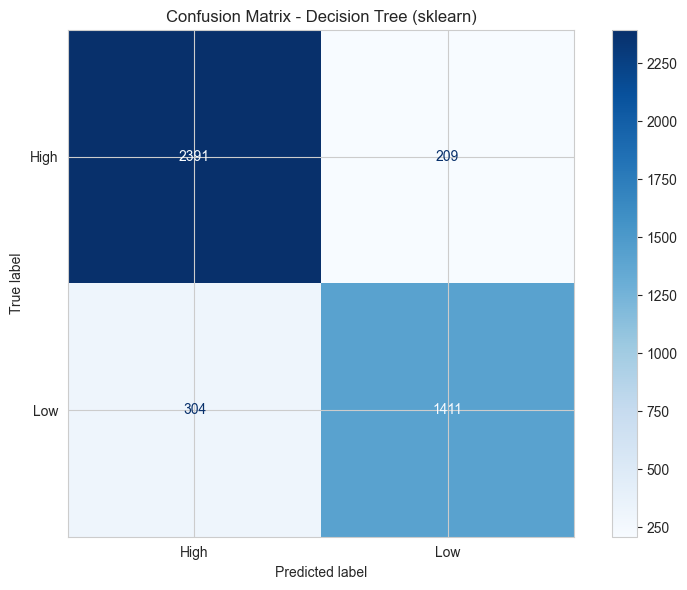

In [13]:
# Trénovanie Decision Tree z scikit-learn
dt_clf = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

dt_clf.fit(X_train_df, y_train_class)

# Predikcia
y_pred_dt_train = dt_clf.predict(X_train_df)
y_pred_dt_test = dt_clf.predict(X_test_df)

# Vyhodnotenie
print("\n📊 Výsledky Decision Tree na TESTOVACÍCH dátach:")
dt_test_metrics = evaluate_classifier(y_test_class, y_pred_dt_test, "Decision Tree (sklearn)")

### 3.2.B - Nestromový algoritmus (1b)


📊 Výsledky Logistic Regression na TESTOVACÍCH dátach:

Logistic Regression - Metriky výkonnosti
Accuracy:  0.6025
Precision: 0.3631
Recall:    0.6025
F1-Score:  0.4531

Detailný classification report:
              precision    recall  f1-score   support

        High       0.60      1.00      0.75      2600
         Low       0.00      0.00      0.00      1715

    accuracy                           0.60      4315
   macro avg       0.30      0.50      0.38      4315
weighted avg       0.36      0.60      0.45      4315



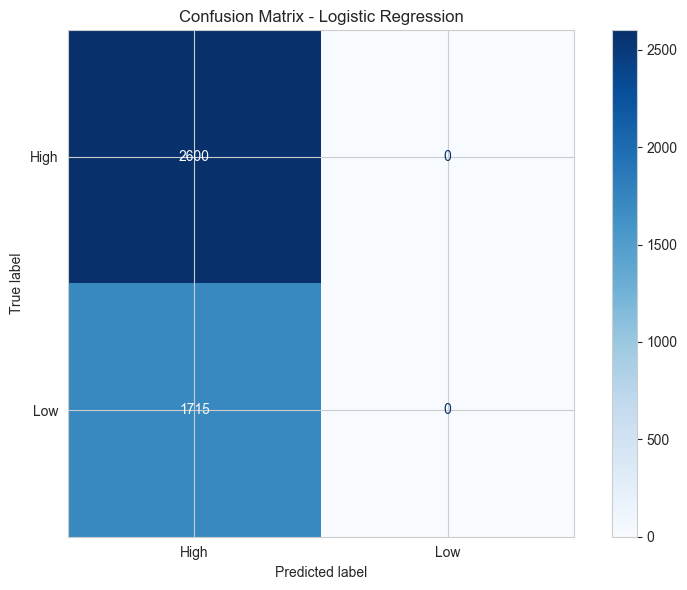

In [14]:
# Trénovanie Logistic Regression
lr_clf = LogisticRegression(
    max_iter=1000,
    random_state=42,
    multi_class='multinomial'
)

lr_clf.fit(X_train_df, y_train_class)

# Predikcia
y_pred_lr_test = lr_clf.predict(X_test_df)

# Vyhodnotenie
print("\n📊 Výsledky Logistic Regression na TESTOVACÍCH dátach:")
lr_test_metrics = evaluate_classifier(y_test_class, y_pred_lr_test, "Logistic Regression")


📊 Výsledky Random Forest na TESTOVACÍCH dátach:

Random Forest - Metriky výkonnosti
Accuracy:  0.8630
Precision: 0.8646
Recall:    0.8630
F1-Score:  0.8635

Detailný classification report:
              precision    recall  f1-score   support

        High       0.90      0.87      0.88      2600
         Low       0.81      0.85      0.83      1715

    accuracy                           0.86      4315
   macro avg       0.86      0.86      0.86      4315
weighted avg       0.86      0.86      0.86      4315



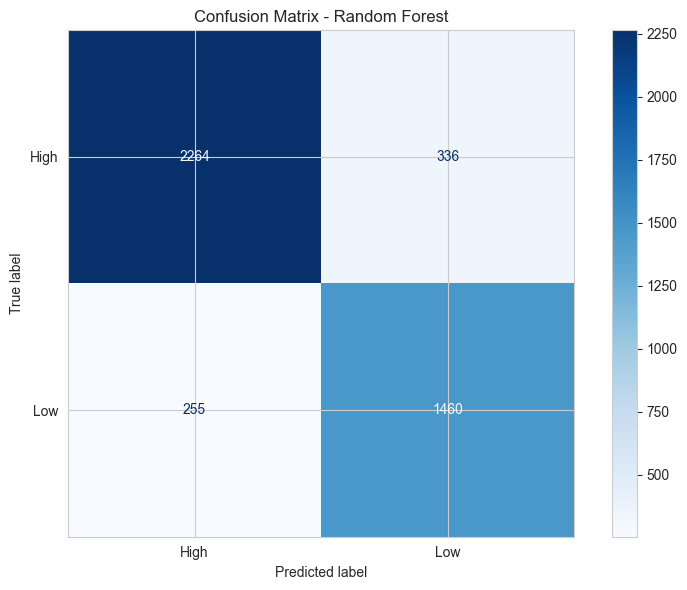

In [15]:
# Alternatívne: Random Forest
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=20,
    random_state=42
)

rf_clf.fit(X_train_df, y_train_class)
y_pred_rf_test = rf_clf.predict(X_test_df)

print("\n📊 Výsledky Random Forest na TESTOVACÍCH dátach:")
rf_test_metrics = evaluate_classifier(y_test_class, y_pred_rf_test, "Random Forest")

### 3.2.C - Porovnanie výsledkov (1b)


📊 POROVNANIE VŠETKÝCH MODELOV
              Model  Accuracy  Precision   Recall  F1-Score
      ID3 (vlastný)  0.797451   0.820461 0.797451  0.799594
      Decision Tree  0.881112   0.880755 0.881112  0.880486
Logistic Regression  0.602549   0.363066 0.602549  0.453110


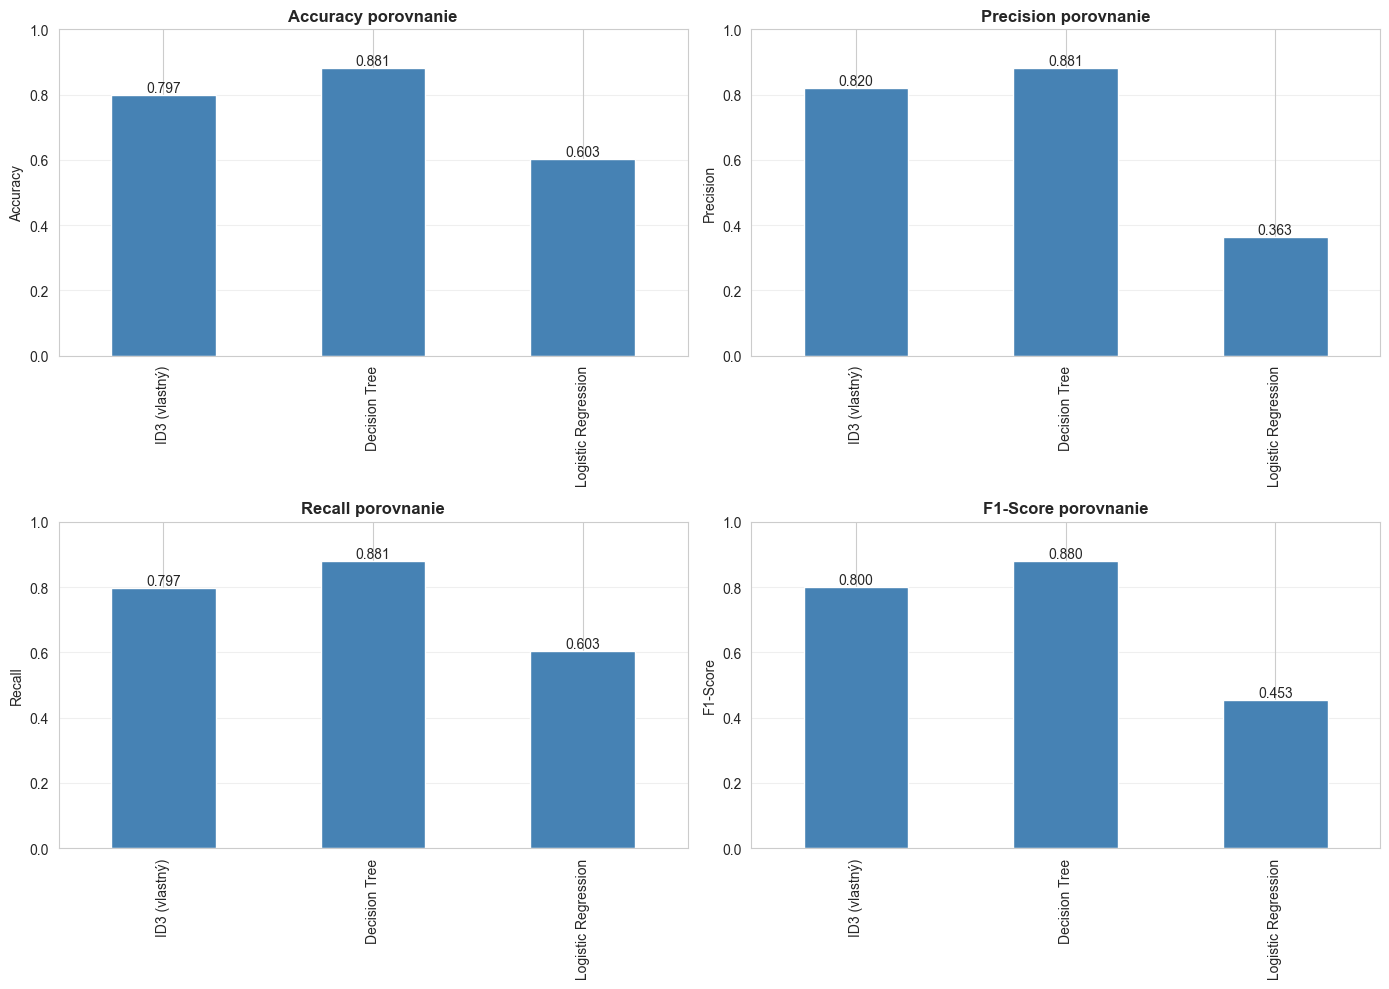

In [16]:
# Vytvorenie porovnávacej tabulky
comparison_df = pd.DataFrame({
    'Model': ['ID3 (vlastný)', 'Decision Tree', 'Logistic Regression'],
    'Accuracy': [
        id3_test_metrics['accuracy'],
        dt_test_metrics['accuracy'],
        lr_test_metrics['accuracy']
    ],
    'Precision': [
        id3_test_metrics['precision'],
        dt_test_metrics['precision'],
        lr_test_metrics['precision']
    ],
    'Recall': [
        id3_test_metrics['recall'],
        dt_test_metrics['recall'],
        lr_test_metrics['recall']
    ],
    'F1-Score': [
        id3_test_metrics['f1_score'],
        dt_test_metrics['f1_score'],
        lr_test_metrics['f1_score']
    ]
})

print("\n" + "="*80)
print("📊 POROVNANIE VŠETKÝCH MODELOV")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

# Vizualizácia porovnania
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for idx, (ax, metric) in enumerate(zip(axes.flat, metrics)):
    comparison_df.plot(x='Model', y=metric, kind='bar', ax=ax, legend=False, color='steelblue')
    ax.set_title(f'{metric} porovnanie', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_xlabel('')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)

    # Pridanie hodnôt na stĺpce
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f')

plt.tight_layout()
plt.show()

### Interpretácia výsledkov

**Poznámky k porovnaniu:**
- ID3 (vlastný): Jednoduchý algoritmus s obmedzenou hĺbkou
- Decision Tree (sklearn): Optimalizovaná implementácia s možnosťou pruning
- Logistic Regression: Lineárny model, vhodný pre lineárne separabilné dáta

**Očakávané výsledky:**
- Stromové algoritmy zvyčajne dobre modelujú nelineárne závislosti
- Logistic Regression môže byť rýchlejšia ale menej výkonná na komplexných dátach
- Decision Tree zo sklearn by mal mať lepšie výsledky ako náš jednoduchý ID3 vďaka pokročilým optimalizáciám

### 3.2.D - Vizualizácia pravidiel (1b)

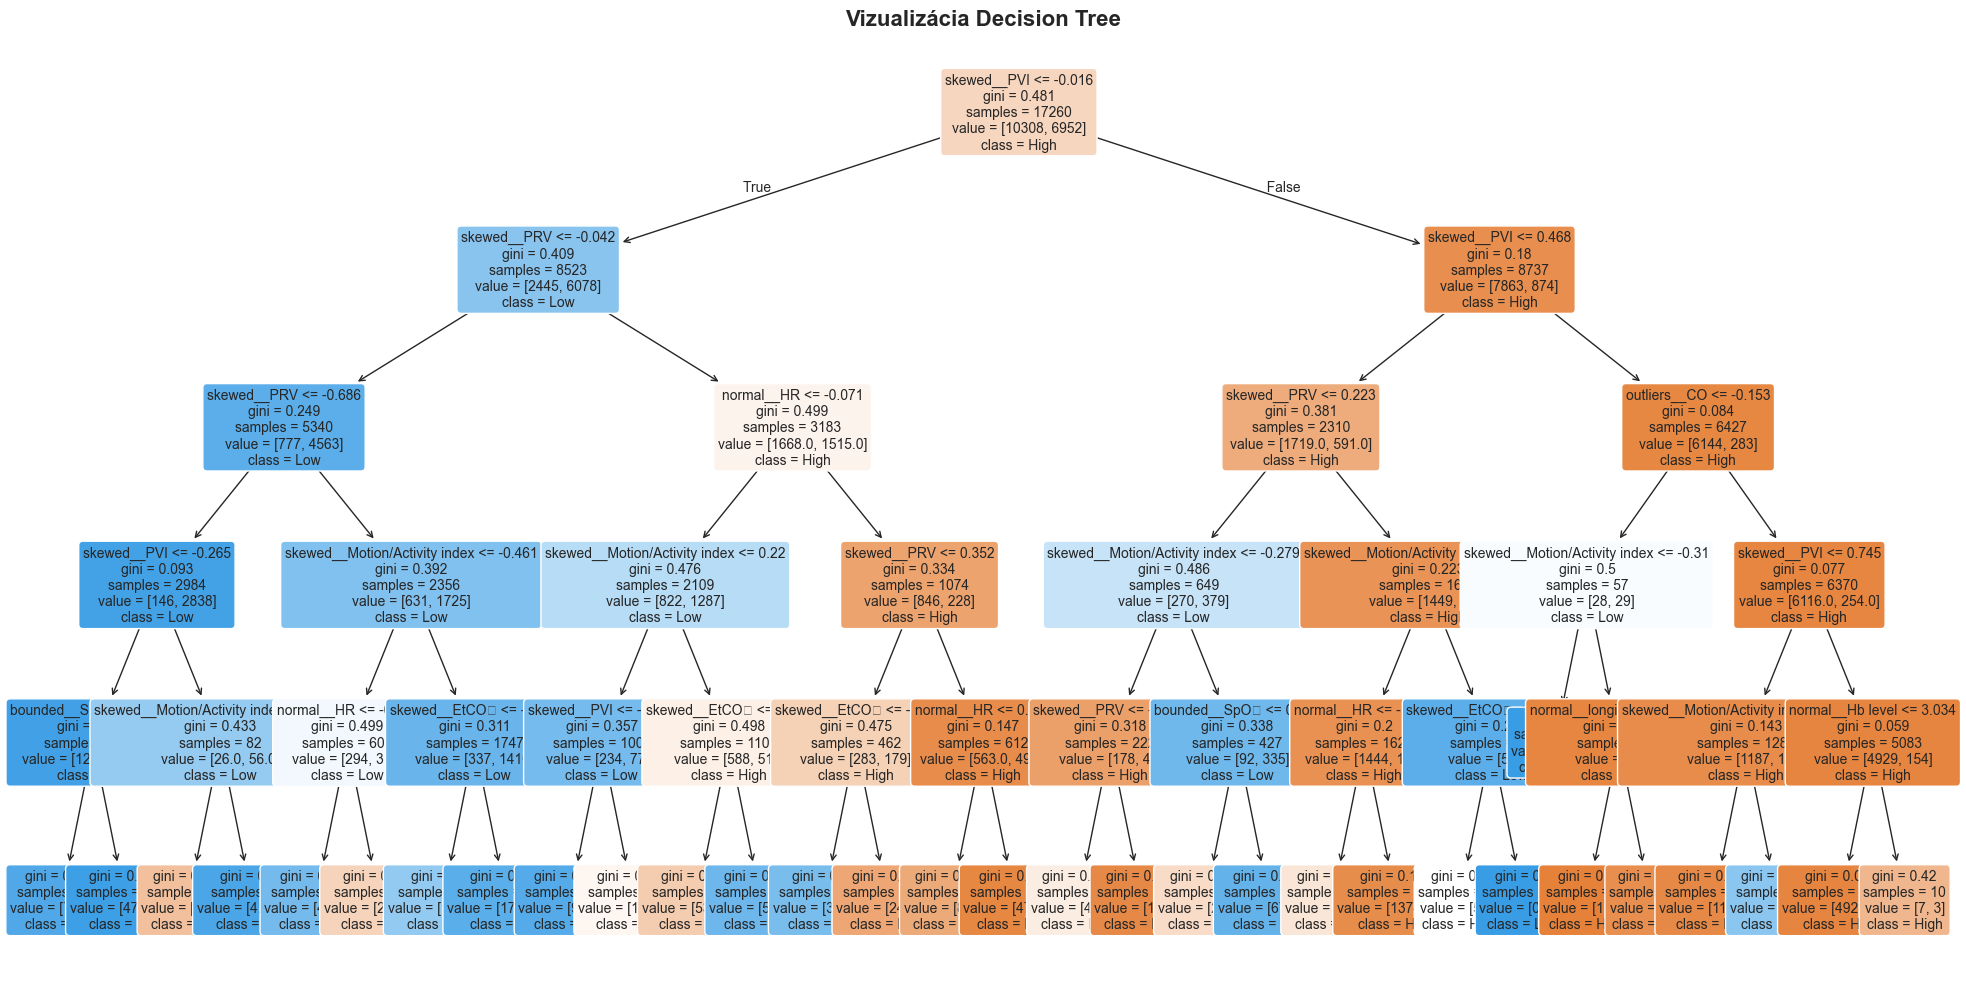


✓ Pravidlá Decision Tree vizualizované


In [17]:
# Vizualizácia Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(
    dt_clf,
    feature_names=X_train_df.columns,
    class_names=[str(c) for c in dt_clf.classes_],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Vizualizácia Decision Tree', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Pravidlá Decision Tree vizualizované")

In [18]:
# Extrakcia textových pravidiel z Decision Tree
from sklearn.tree import export_text

tree_rules = export_text(
    dt_clf,
    feature_names=list(X_train_df.columns),
    max_depth=3
)

print("\n📋 Pravidlá Decision Tree (prvé 3 úrovne):")
print("="*60)
print(tree_rules)


📋 Pravidlá Decision Tree (prvé 3 úrovne):
|--- skewed__PVI <= -0.02
|   |--- skewed__PRV <= -0.04
|   |   |--- skewed__PRV <= -0.69
|   |   |   |--- skewed__PVI <= -0.27
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- skewed__PVI >  -0.27
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- skewed__PRV >  -0.69
|   |   |   |--- skewed__Motion/Activity index <= -0.46
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- skewed__Motion/Activity index >  -0.46
|   |   |   |   |--- truncated branch of depth 2
|   |--- skewed__PRV >  -0.04
|   |   |--- normal__HR <= -0.07
|   |   |   |--- skewed__Motion/Activity index <= 0.22
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- skewed__Motion/Activity index >  0.22
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- normal__HR >  -0.07
|   |   |   |--- skewed__PRV <= 0.35
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- skewed__PRV >  0.35
|   |   |   |   |--- t

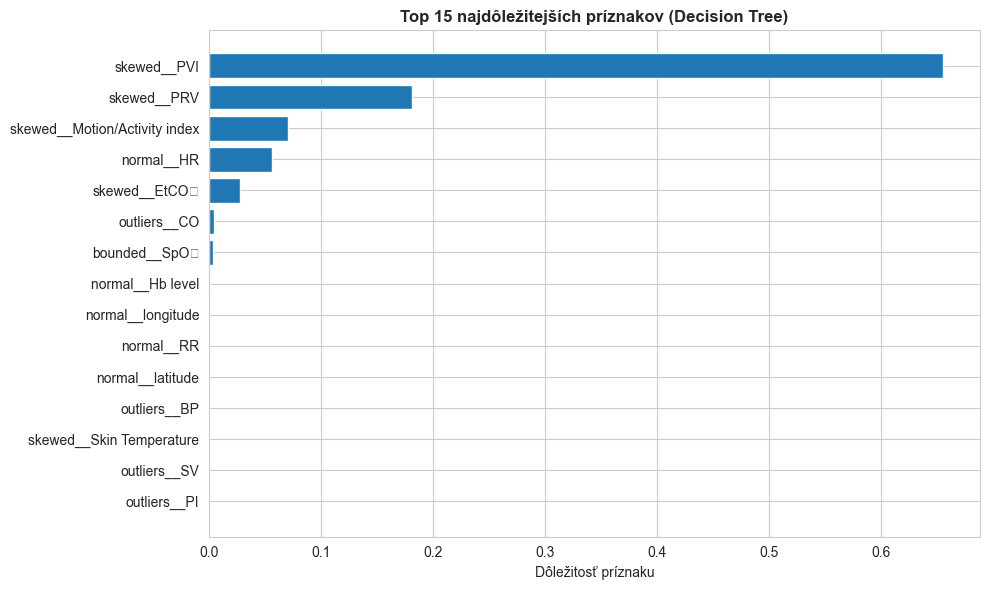


Top 10 najdôležitejších príznakov:
                      feature  importance
                  skewed__PVI    0.656060
                  skewed__PRV    0.180803
skewed__Motion/Activity index    0.070423
                   normal__HR    0.056522
                skewed__EtCO₂    0.027447
                 outliers__CO    0.004690
                bounded__SpO₂    0.003755
             normal__Hb level    0.000275
            normal__longitude    0.000025
                   normal__RR    0.000000


In [19]:
# Feature importance z Decision Tree
feature_importance = pd.DataFrame({
    'feature': X_train_df.columns,
    'importance': dt_clf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'][:15], feature_importance['importance'][:15])
plt.xlabel('Dôležitosť príznaku')
plt.title('Top 15 najdôležitejších príznakov (Decision Tree)', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 najdôležitejších príznakov:")
print(feature_importance.head(10).to_string(index=False))

### 3.2.E - Súhrnné vyhodnotenie (1b)

In [20]:
# Cross-validation pre robustnejšie vyhodnotenie
print("\n🔄 Cross-validation (5-fold) pre všetky modely:\n")

models = {
    'Decision Tree': dt_clf,
    'Logistic Regression': lr_clf,
}

cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train_df, y_train_class, cv=5, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name}:")
    print(f"  Priemerne: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")
    print(f"  Min: {scores.min():.4f}, Max: {scores.max():.4f}\n")


🔄 Cross-validation (5-fold) pre všetky modely:

Decision Tree:
  Priemerne: 0.8758 (+/- 0.0067)
  Min: 0.8694, Max: 0.8786

Logistic Regression:
  Priemerne: 0.5972 (+/- 0.0003)
  Min: 0.5970, Max: 0.5973



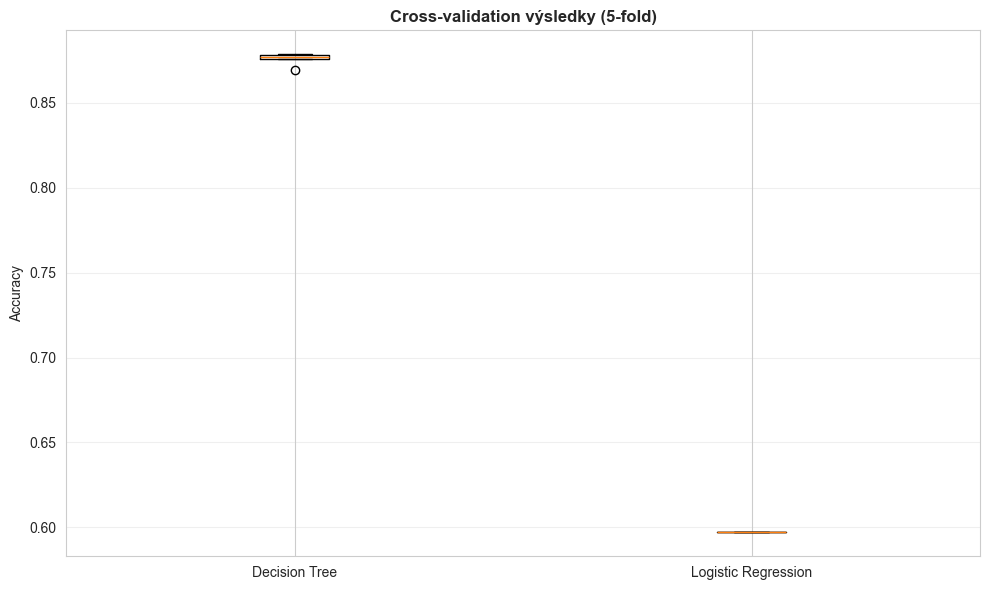

In [21]:
# Vizualizácia cross-validation výsledkov
plt.figure(figsize=(10, 6))
plt.boxplot(cv_results.values(), labels=cv_results.keys())
plt.ylabel('Accuracy')
plt.title('Cross-validation výsledky (5-fold)', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Záver

### Zhrnutie výsledkov

V tejto fáze sme:
1. ✅ Implementovali vlastný ID3 klasifikátor s hĺbkou minimálne 2
2. ✅ Vyhodnotili ID3 pomocou metrík accuracy, precision a recall
3. ✅ Analyzovali a riešili overfit
4. ✅ Porovnali s algoritmami zo scikit-learn (Decision Tree a Logistic Regression)
5. ✅ Vizualizovali natrénované pravidlá

### Kľúčové zistenia

*[Vyplňte na základe vašich výsledkov]*

- Najlepší model: ...
- Accuracy: ...
- Dôležité príznaky: ...

### Odporúčania pre ďalšiu prácu

- Experimentovanie s ensemble metódami (Random Forest, Gradient Boosting)
- Optimalizácia hyperparametrov pomocou Grid Search alebo Random Search
- Skúšanie pokročilejších feature engineering techník

## Uloženie výsledkov

In [22]:
# Uloženie najlepšieho modelu
# best_model = dt_clf  # Zmeňte na základe výsledkov
# joblib.dump(best_model, 'phase3_best_model.pkl')
# print("✓ Najlepší model uložený do 'phase3_best_model.pkl'")

# # Uloženie výsledkov porovnania
# comparison_df.to_csv('phase3_model_comparison.csv', index=False)
# print("✓ Porovnanie modelov uložené do 'phase3_model_comparison.csv'")